# MARL-Gated RALA Vision Transformer (v2)

**Corrected Implementation** — Fixes relative to `ViT copy.ipynb`:
1. **Multi-agent**: single SharedActorCritic at ViT level, passed to every layer
2. **MARL gating** replaces RALA's α_j reweighting; keeps Hadamard product output gate
3. **State dilution** term Γ_τ in recurrent memory
4. **Proper PPO** with rollout buffer (old log_probs, actual ratio)
5. **Correct squashed Gaussian entropy** with Jacobian correction
6. **Per-token critic** values (not per-chunk)
7. **Fisher target** computed per-token (averaged over heads)

---

### Training Pipeline
- **Stage 1:** Pure Backbone Pre-training (Learn Spatial Geometry)
- **Stage 2:** Router Warm-up via Fisher Information (Frozen Backbone)
- **Stage 3:** End-to-End PPO Fine-Tuning (Budget Constraint)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
from torchvision import transforms
from datasets import load_dataset
from einops import rearrange
from tqdm import tqdm
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

## 1. Dataset & Transformations
**Run this cell once** — the dataset stays in memory for all subsequent cells.

In [2]:
transform = transforms.Compose([
    transforms.Resize((144, 144)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class HFImageNetDataset(torch.utils.data.Dataset):
    def __init__(self, hf_split, transform=None):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        image = item['image']
        label = item['label']
        if image.mode != 'RGB':
            image = image.convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Loading ImageNet-100 from Hugging Face...")
hf_train = load_dataset("clane9/imagenet-100", split="train")
hf_val = load_dataset("clane9/imagenet-100", split="validation")

batch_size = 64
train_dataset = HFImageNetDataset(hf_train, transform=transform)
val_dataset = HFImageNetDataset(hf_val, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=0, pin_memory=True if torch.cuda.is_available() else False
)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=0, pin_memory=True if torch.cuda.is_available() else False
)

print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images")
print(f"Batch size: {batch_size} | Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Using device: cuda
Loading ImageNet-100 from Hugging Face...


Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Train: 126689 images | Val: 5000 images
Batch size: 64 | Train batches: 1980 | Val batches: 79


## 2. Architecture Definitions

In [3]:
class SimpleRouter(nn.Module):
    """
    Simple MLP Router that outputs a deterministic Sigmoid value w_t in (0, 1) per token.
    """
    def __init__(self, d_model: int):
        super().__init__()
        half = max(d_model // 2, 16)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, half),
            nn.ELU(),
            nn.Linear(half, 1)
        )

    def forward(self, local_features: torch.Tensor):
        logits = self.mlp(local_features).squeeze(-1) # (B, N)
        w = torch.sigmoid(logits)
        return w


class ChunkwiseRALAAttention(nn.Module):
    """
    Chunkwise Linear Attention with MARL gating.
    
    Based on RALA but replaces α_j reweighting with MARL agent weights:
    - κ(·) = ELU(·) + 1.0 kernel function
    - MARL gating: w_t from shared Actor-Critic replaces RALA's α_j
    - Output modulation: Y_i = φ(X_i) ⊙ (κ(Q_i) · S_t) — Hadamard product gate
    
    The router is NOT internal — weights are passed from outside.
    """
    def __init__(self, d_model: int, head: int = 8, chunk_size: int = 16,
                 gamma: float = 0.1, dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model
        self.head = head
        self.chunk_size = chunk_size
        self.gamma = gamma
        self.d_k = d_model // head

        # QKV projection
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)

        # Output gate: φ(X) for Hadamard product modulation
        self.w_o_gate = nn.Linear(d_model, d_model)

        # Output projection
        self.w_o_proj = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, w_gating, use_dilution=False):
        """
        Args:
            x:            (B, N, d_model)
            w_gating:     (B, N) — per-token gating weights from the shared AC
            use_dilution: bool — enable state dilution Γ_τ (Phase 2/3)
        Returns:
            out:  (B, N, d_model) — attention output
            phi_k: for Fisher info computation (gradients flow through here)
        """
        b, n, d = x.shape
        T = n // self.chunk_size
        C = self.chunk_size

        # --- Linear projections ---
        q = rearrange(self.w_q(x), 'b (T C) (h dk) -> b T h C dk',
                       T=T, C=C, h=self.head)
        k = rearrange(self.w_k(x), 'b (T C) (h dk) -> b T h C dk',
                       T=T, C=C, h=self.head)
        v = rearrange(self.w_v(x), 'b (T C) (h dk) -> b T h C dk',
                       T=T, C=C, h=self.head)

        # Scaling
        q = q * (self.d_k ** -0.25)
        k = k * (self.d_k ** -0.25)

        # --- Kernel function: κ(·) = ELU(·) + 1 ---
        phi_q = F.elu(q) + 1.0  # (B, T, h, C, dk)
        phi_k = F.elu(k) + 1.0  # (B, T, h, C, dk)

        # --- Apply MARL gating directly to φ(K) ---
        # MARL agents replace RALA's α_j: each agent's weight gates its token's key
        # w_gating: (B, N) -> reshape to (B, T, C) -> expand to (B, T, 1, C, 1)
        w_chunks = rearrange(w_gating, 'b (T C) -> b T C', T=T, C=C)
        w_expanded = w_chunks.unsqueeze(2).unsqueeze(-1)  # (B, T, 1, C, 1)
        k_gated = w_expanded * phi_k                      # (B, T, h, C, dk)

        # --- Chunk-level KV computation ---
        k_gated_f32 = k_gated.to(torch.float32)
        v_f32 = v.to(torch.float32)
        KV_chunks = torch.matmul(k_gated_f32.transpose(-2, -1), v_f32)  # (B,T,h,dk,dk)
        Z_chunks = k_gated_f32.sum(dim=-2)                               # (B,T,h,dk)

        # --- Chunk-level average gating weight w̄_t ---
        w_bar = w_chunks.mean(dim=-1)  # (B, T)

        # --- Sequential recurrence ---
        outputs = []
        S = torch.zeros(b, self.head, self.d_k, self.d_k,
                        device=x.device, dtype=torch.float32)
        Z = torch.zeros(b, self.head, self.d_k,
                        device=x.device, dtype=torch.float32)

        for t in range(T):
            # Decay: 1 - γ(1 - w̄_t)
            decay_factor = 1.0 - (self.gamma * (1.0 - w_bar[:, t]))
            decay_S = decay_factor.view(b, 1, 1, 1)
            decay_Z = decay_factor.view(b, 1, 1)

            # State dilution term Γ_τ (Eq. 11 from approach.tex)
            if use_dilution and t > 0:
                dilution_scale = self.gamma * (1.0 - w_bar[:, t])  # (B,)
                gamma_tau = dilution_scale.view(b, 1, 1, 1) * S / max(t, 1)
                S = (S * decay_S) + KV_chunks[:, t] + gamma_tau
            else:
                S = (S * decay_S) + KV_chunks[:, t]

            Z = (Z * decay_Z) + Z_chunks[:, t]

            # Attention output for chunk t
            phi_q_t = phi_q[:, t].to(torch.float32)          # (B, h, C, dk)
            nom = torch.matmul(phi_q_t, S)                   # (B, h, C, dk)
            denom = (phi_q_t * Z.unsqueeze(-2)).sum(dim=-1, keepdim=True) + 1e-5

            out_t = nom / denom

            if self.training:
                out_t = self.dropout(out_t)

            out_t = torch.clamp(out_t, min=-65000.0, max=65000.0)
            outputs.append(out_t.to(q.dtype))

        out = torch.stack(outputs, dim=1)                    # (B, T, h, C, dk)
        out = rearrange(out, 'b T h C dk -> b (T C) (h dk)')

        # --- Output modulation: Y = φ(X) ⊙ attn_output ---
        gate = torch.sigmoid(self.w_o_gate(x))                # (B, N, d)
        out = out * gate

        out = self.w_o_proj(out)

        return out, phi_k


class PatchEmbedding(nn.Module):
    def __init__(self, image_size=144, patch_size=12, in_chans=3, embed_dim=256):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)


class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, drop=0.):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))


class EncoderBlock(nn.Module):
    """
    A single encoder block. The attention module does NOT own a router.
    The router (SharedActorCritic) lives at the ViT level.
    """
    def __init__(self, d_model, head, chunk_size):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = ChunkwiseRALAAttention(d_model, head=head, chunk_size=chunk_size)
        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = MLP(d_model, d_model * 4)

    def forward(self, x, w_gating, use_dilution=False):
        res = x
        x_normed = self.norm1(x)
        out, phi_k = self.attn(x_normed, w_gating, use_dilution)
        x = res + out
        x = x + self.mlp(self.norm2(x))
        return x, phi_k

class ViT(nn.Module):
    def __init__(self, image_size=144, patch_size=12, num_classes=100,
                 d_model=256, depth=6, head=8, chunk_size=16):
        super().__init__()
        self.depth = depth
        self.patch_embed = PatchEmbedding(image_size, patch_size, 3, d_model)
        self.pos_embed = nn.Parameter(
            torch.zeros(1, self.patch_embed.num_patches, d_model))
        self.blocks = nn.ModuleList([
            EncoderBlock(d_model, head, chunk_size) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, num_classes)

        # Simple continuous sigmoid router
        self.router = SimpleRouter(d_model)

    def forward(self, x, use_dilution=False):
        x = self.patch_embed(x) + self.pos_embed  # (B, N, d)

        w_list = []
        for block in self.blocks:
            w = self.router(x)
            x, phi_k = block(x, w, use_dilution)
            w_list.append(w)

        x = self.norm(x)
        logits = self.head(x.mean(dim=1))  # (B, num_classes)

        return {
            'logits': logits,
            'w_t': torch.stack(w_list, dim=1), # (B, L, N)
        }



## 3. Evaluation & Sanity Check

In [4]:
@torch.no_grad()
def evaluate(model, val_loader, device, phase_name, epoch):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss()

    print(f"\n--- Running Validation ({phase_name} | Epoch {epoch+1}) ---")
    for images, labels in tqdm(val_loader, desc="Evaluating", leave=False):
        images, labels = images.to(device), labels.to(device)

        with torch.autocast(device_type=device.type):
            outputs = model(images, deterministic=True)
            logits = outputs['logits']
            loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total * 100.0
    print(f"Validation: Loss={avg_loss:.4f} | Accuracy={accuracy:.2f}%\n")
    model.train()


def sanity_check_overfit(model, train_loader, device, epochs=50):
    print("\n--- Pre-Flight Check: Single-Batch Overfit ---")
    model.train()
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.0)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == 'cuda')

    images, labels = next(iter(train_loader))
    images, labels = images.to(device), labels.to(device)

    loop = tqdm(range(epochs), desc="Overfitting Single Batch")
    for _ in loop:
        optimizer.zero_grad()
        with torch.autocast(device_type=device.type):
            outputs = model(images, deterministic=True)
            logits = outputs['logits']
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        preds = logits.argmax(dim=-1)
        acc = (preds == labels).float().mean().item() * 100.0
        loop.set_postfix(Loss=f"{loss.item():.4f}", Acc=f"{acc:.1f}%")


## 4. Training Stage 1: Pure Backbone Pre-training

## 5. Training Stage 2: Router Warm-up via Fisher Information

## 6. Training Stage 3: End-to-End PPO Fine-tuning

In [57]:
def compute_bimodal_sparsity(w_t):
    """
    Bimodal sparsity penalty: w * (1 - w)
    """
    return (w_t * (1.0 - w_t)).mean()

def train_end_to_end(model, train_loader, val_loader, epochs, device,
                     lambda_budget=2.0, lambda_sparse=1.0):
    """
    Single Phase End-to-end continuous sigmoid routing.
    Gradients flow directly through the sigmoid into the router parameters.
    """
    print("\n--- Starting End-to-End Sigmoid Fine-tuning ---")
    print(f"    lambda_budget={lambda_budget}, lambda_sparse={lambda_sparse}")
    model.train()

    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    criterion_ce_none = nn.CrossEntropyLoss(reduction='none')
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == 'cuda')
    
    import os
    os.makedirs(f'checkpoints_sigmoid/{lambda_budget},{lambda_sparse}', exist_ok=True)

    for epoch in range(epochs):
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.autocast(device_type=device.type):
                outputs = model(images, use_dilution=True)
                logits = outputs['logits']
                w_t = outputs['w_t']

                loss_ce = criterion_ce_none(logits, labels).mean()
                budget_loss = lambda_budget * w_t.mean()
                sparse_loss = lambda_sparse * compute_bimodal_sparsity(w_t)
                
                total_loss = loss_ce + budget_loss + sparse_loss

            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            preds = logits.argmax(dim=-1)
            acc = (preds == labels).float().mean().item() * 100
            loop.set_postfix(
                CE=f"{loss_ce.item():.3f}",
                Bdgt=f"{budget_loss.item():.3f}",
                Sprs=f"{sparse_loss.item():.3f}",
                R=f"{w_t.mean().item()*100:.1f}%",
                Acc=f"{acc:.1f}%"
            )

        ckpt_path = f'checkpoints_sigmoid/{lambda_budget},{lambda_sparse}/sigmoid_vit_epoch{epoch+1}.pth'
        torch.save(model.state_dict(), ckpt_path)
        print(f'    [SAVED] {ckpt_path}')

        evaluate(model, val_loader, device, "E2E", epoch)



## 7. Visualizer

In [27]:
@torch.no_grad()
def visualize_routing_decisions(model_path, dataset, device, image_index=0):
    print("Loading trained weights...")
    model = ViT(
        image_size=144, patch_size=12, num_classes=100,
        d_model=256, depth=16, head=8, chunk_size=16
    ).to(device)

    model.load_state_dict(torch.load(model_path, map_location=device,
                                     weights_only=True))
    model.eval()

    image_tensor, label_idx = dataset[image_index]
    image_batch = image_tensor.unsqueeze(0).to(device)

    outputs = model(image_batch, deterministic=True)
    w_t = outputs['w_t']   # (1, L, N)
    logits = outputs['logits']

    pred_idx = logits.argmax(dim=-1).item()

    try:
        hf_features = dataset.hf_split.features['label']
        true_name = hf_features.int2str(label_idx)
        pred_name = hf_features.int2str(pred_idx)
    except:
        true_name = f"Class {label_idx}"
        pred_name = f"Class {pred_idx}"

    # Average across layers: (1, L, N) -> (N,)
    routing_weights = w_t[0].mean(dim=0).cpu().numpy()
    grid_size = int(math.sqrt(len(routing_weights)))
    heatmap = routing_weights.reshape(grid_size, grid_size)

    # Denormalize
    img_np = image_tensor.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    heatmap_resized = cv2.resize(heatmap, (144, 144),
                                  interpolation=cv2.INTER_CUBIC)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    title_color = "green" if label_idx == pred_idx else "red"
    axes[0].imshow(img_np)
    axes[0].set_title(f"True: {true_name}\nPred: {pred_name}",
                      color=title_color, fontweight='bold')
    axes[0].axis('off')

    im = axes[1].imshow(heatmap_resized, cmap='jet', alpha=0.8, vmin=0, vmax=1)
    axes[1].set_title("MARL Agent Routing Map (w_t)")
    axes[1].axis('off')
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(img_np)
    axes[2].imshow(heatmap_resized, cmap='jet', alpha=0.4, vmin=0, vmax=1)
    axes[2].set_title("Overlay (High value = Retained)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


## 8. Initialize Model & Sanity Check
Re-run this cell to reinitialize a fresh model.

In [18]:
model = ViT(
    image_size=144, patch_size=12, num_classes=100,
    d_model=256, depth=16, head=8, chunk_size=16
).to(device)

print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Router params: {sum(p.numel() for n, p in model.named_parameters() if 'router' in n):,}")

sanity_check_overfit(model, train_loader, device, epochs=50)

Total params: 13,929,063
Router params: 66,307

--- Pre-Flight Check: Single-Batch Overfit ---


Overfitting Single Batch: 100%|██████████| 50/50 [00:39<00:00,  1.27it/s, Acc=100.0%, Loss=0.0207]


## 9. Stage 1: Backbone Pre-training
Re-initialize model before running this.

In [19]:
model = ViT(
    image_size=144, patch_size=12, num_classes=100,
    d_model=256, depth=16, head=8, chunk_size=16
).to(device)

train_stage_1_backbone(model, train_loader, val_loader, epochs=20, device=device)
torch.save(model.state_dict(), "vit_v2_stage_1_backbone.pth")
print("✅ Stage 1 checkpoint saved.")


--- Starting Stage 1: Pure Backbone Pre-training ---


Stage 1 Epoch [5/20]: 100%|██████████| 1980/1980 [29:16<00:00,  1.13it/s, Acc=15.2%, CE=3.12]



--- Running Validation (Stage 1 | Epoch 5) ---


Validation: Loss=2.9936 | Accuracy=25.52%



Stage 1 Epoch [10/20]: 100%|██████████| 1980/1980 [28:39<00:00,  1.15it/s, Acc=24.2%, CE=2.69]


...


--- Running Validation (Stage 1 | Epoch 15) ---


Validation: Loss=2.3322 | Accuracy=39.76%



Stage 1 Epoch [20/20]: 100%|██████████| 1980/1980 [28:28<00:00,  1.16it/s, Acc=60.6%, CE=1.29]



--- Running Validation (Stage 1 | Epoch 20) ---


Validation: Loss=2.1320 | Accuracy=45.14%

✅ Stage 1 checkpoint saved.


## 10. Stage 2: Router Warm-up (Fisher Information)
Continues from Stage 1 checkpoint.

## 11. Stage 3: PPO Fine-tuning
Continues from Stage 2 checkpoint.

In [ ]:
def compute_bimodal_sparsity(w_t):
    """
    Bimodal sparsity penalty: w * (1 - w)
    """
    return (w_t * (1.0 - w_t)).mean()

def train_end_to_end(model, train_loader, val_loader, epochs, device,
                     lambda_budget=2.0, lambda_sparse=1.0):
    """
    Single Phase End-to-end continuous sigmoid routing.
    Gradients flow directly through the sigmoid into the router parameters.
    """
    print("\n--- Starting End-to-End Sigmoid Fine-tuning ---")
    print(f"    lambda_budget={lambda_budget}, lambda_sparse={lambda_sparse}")
    model.train()

    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    criterion_ce_none = nn.CrossEntropyLoss(reduction='none')
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == 'cuda')
    
    import os
    os.makedirs(f'checkpoints_sigmoid/{lambda_budget},{lambda_sparse}', exist_ok=True)

    for epoch in range(epochs):
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.autocast(device_type=device.type):
                outputs = model(images, use_dilution=True)
                logits = outputs['logits']
                w_t = outputs['w_t']

                loss_ce = criterion_ce_none(logits, labels).mean()
                budget_loss = lambda_budget * w_t.mean()
                sparse_loss = lambda_sparse * compute_bimodal_sparsity(w_t)
                
                total_loss = loss_ce + budget_loss + sparse_loss

            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            preds = logits.argmax(dim=-1)
            acc = (preds == labels).float().mean().item() * 100
            loop.set_postfix(
                CE=f"{loss_ce.item():.3f}",
                Bdgt=f"{budget_loss.item():.3f}",
                Sprs=f"{sparse_loss.item():.3f}",
                R=f"{w_t.mean().item()*100:.1f}%",
                Acc=f"{acc:.1f}%"
            )

        ckpt_path = f'checkpoints_sigmoid/{lambda_budget},{lambda_sparse}/sigmoid_vit_epoch{epoch+1}.pth'
        torch.save(model.state_dict(), ckpt_path)
        print(f'    [SAVED] {ckpt_path}')

        evaluate(model, val_loader, device, "E2E", epoch)




--- Starting Stage 3: End-to-End MARL PPO Fine-tuning ---


Stage 3 Epoch [5/10]: 100%|██████████| 1980/1980 [46:39<00:00,  1.41s/it, Acc=54.5%, CE=1.53, PPO=0.723, Retained=49.7%] 



--- Running Validation (Stage 3 | Epoch 5) ---


Validation: Loss=1.9568 | Accuracy=49.10%



Stage 3 Epoch [10/10]: 100%|██████████| 1980/1980 [47:05<00:00,  1.43s/it, Acc=78.8%, CE=1.15, PPO=0.755, Retained=49.6%] 



--- Running Validation (Stage 3 | Epoch 10) ---


Validation: Loss=1.9391 | Accuracy=50.30%

✅ Stage 3 checkpoint saved.


## 12. Visualization

Loading trained weights...


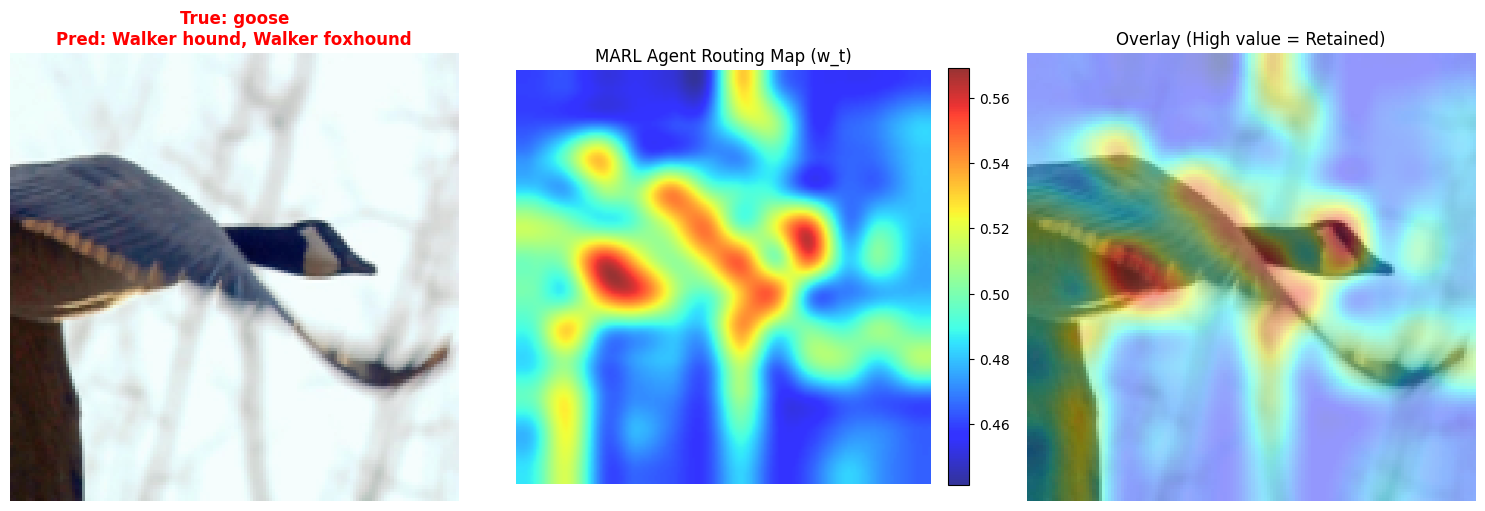

In [49]:
# Evaluate routing map at the end
visualize_routing_decisions(
    f"checkpoints_sigmoid/2.0,1.0/sigmoid_vit_epoch10.pth", 
    val_dataset, 
    device, 
    image_index=4900
)
